# Lista 2 - Tópicos Avançados em Aprendizagem de máquina
- Aluno: Lucas Rodrigues Aragão (538390) - Graduação

### Imports e framework Numpy da lista 1

In [153]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.datasets import make_moons

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from datasets import load_dataset

from collections import Counter
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Configurações de estilo para os gráficos

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 14})

Framework Numpy da lista 1

In [16]:
class Differentiable:
    """Classe base para todas as funcionalidades diferenciáveis."""
    def forward(self, input_data):
        raise NotImplementedError
    def backward(self, output_grad):
        raise NotImplementedError

class Layer(Differentiable):
    """Classe base para todas as camadas da rede neural com paraâmetros."""
    def forward(self, input_data):
        raise NotImplementedError
    def backward(self, output_grad):
        raise NotImplementedError
    def params(self):
        """Retorna os parâmetros e gradientes da camada."""
        return [], []

def sigmoide(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

class Linear(Layer):
    def __init__(self, input_size, output_size):
        self.W = np.random.randn(input_size, output_size) * 0.1
        self.b = np.zeros((1, output_size))
        self.input_data = None
        self.dW = np.zeros_like(self.W)
        self.db = np.zeros_like(self.b)
        self.input_size = input_size
        self.output_size = output_size

    def forward(self, input_data):
        self.input_data = input_data
        return np.dot(input_data, self.W) + self.b

    def backward(self, output_grad):
        # gradientes
        self.dW = np.dot(self.input_data.T, output_grad)
        self.db = np.sum(output_grad, axis=0, keepdims=True)
        # gradiente para trás
        dx = np.dot(output_grad, self.W.T)
        return dx

    def params(self):
        return [(self.W, self.dW), (self.b, self.db)]

class Sigmoid(Differentiable):
    def __init__(self):
        self.output = None

    def forward(self, input_data):
        # Armazene o resultado em self.output para usar no backward pass.
        self.output = sigmoide(input_data)
        return self.output

    def backward(self, output_grad):
        # sigma'(z) = sigma(z) * (1 - sigma(z))
        return output_grad * (self.output * (1 - self.output))

class ReLU(Differentiable):
    def __init__(self):
        self.output = None

    def forward(self, input_data):
        # Armazene o resultado em self.output para usar no backward pass.
        self.output = relu(input_data)
        return self.output

    def backward(self, output_grad):
        
        # A derivada é output_grad * relu'(z).
        #return output_grad * self.output
        return output_grad * (self.output > 0).astype(float)

class MSELoss(Differentiable):
    def forward(self, y_pred, y_true):
        # TODO: Implementar o cálculo do Erro Quadrático Médio (MSE).
        self.y_pred = y_pred
        self.y_true = y_true
        return np.mean((y_pred - y_true)**2)

    def backward(self):
        n = len(self.y_true)
        return 2 * (self.y_pred - self.y_true) / n

class BinaryCrossEntropyLoss(Differentiable):
    def forward(self, y_pred, y_true):
        # evitar log(0)
        self.y_pred = np.clip(y_pred, 1e-12, 1 - 1e-12)
        self.y_true = y_true
        return -np.mean(
            y_true * np.log(self.y_pred) + (1 - y_true) * np.log(1 - self.y_pred)
        )
    
    def backward(self):
        n = self.y_true.shape[0]  
        return (self.y_pred - self.y_true) / (n * self.y_pred * (1 - self.y_pred))

class Sequential(Layer):
    def __init__(self, layers):
        self.layers = layers

    def forward(self, input_data):
        for layer in self.layers:
            input_data = layer.forward(input_data)
        return input_data

    def backward(self, output_grad):
        for layer in reversed(self.layers):
            output_grad = layer.backward(output_grad)
            
    def params(self):
        parameters = []
        for layer in self.layers:
            if hasattr(layer,"params"):
                parameters.extend(layer.params())
        return parameters

class SGD:
    def __init__(self, model, learning_rate):
        self.model = model
        self.learning_rate = learning_rate
    def step(self):
        for param, grad in self.model.params():
            param -= self.learning_rate * grad  
            
    def zero_grad(self):
        for _, grad in self.model.params():
            grad[...] = 0  

## Parte 1 -  Exercícios teóricos e práticos 

### Exercício 1: Teoria da convergência
Responda brevemente:

**1. Adam é frequentemente o otimizador padrão, mas em alguns trabalhos de pesquisa, o bom e velho SGD com Momento alcança um erro de generalização final ligeiramente melhor. Com base na nossa discussão sobre mínimos planos vs. afiados, formule uma hipótese para explicar por que isso pode acontecer. (Dica: pense em como a taxa de aprendizado adaptativa do Adam pode se comportar em diferentes geometrias de mínimos).**

**Resposta:** 

Como mostrado em sala, o ruído inerente do SGD pode ajudar ele a escapar de mínimos afiados. No caso do Adam, devido à forma como os parâmetros atualizam, é possível que o otimizador acabe olhando aquele mínimo afiado como o melhor possível e acabe prejudicando a capacidade de generalização do modelo. Isso pode ser explicado pelo fato da taxa adaptativa diminuir o "learning rate" de passos com gradientes muito altos, ou seja, em regiões muito afiadas, que possuem gradientes altos, o otimizador tende a ficar preso nelas. Por isso em determinadas situações o SGD consegue generalizar melhor funções, uma vez que sua taxa de aprendizado é fixa, e por isso, ele consegue escapar dos mínimos afiados, buscando regiões de mínimos planos.

### Exercício 2: Descida de gradiente ruidosa
Neste exercício, vamos explorar uma versão da Descida de Gradiente onde injetamos ruído
Gaussiano explicitamente a cada passo de duas formas. A regra de atualização é:

$$\theta_{t+1} \leftarrow \theta_t - \eta(\nabla J (\theta_t) + \epsilon_t) \text{, onde } \epsilon \sim \mathcal{N} (0, \sigma^2 I)$$

#### Parte A - Implementação (NumPy):
Crie uma nova classe de otimizador, `NoisyGD`, no seu framework NumPy. O construtor deve receber o modelo, a taxa de aprendizado `learning_rate` e um novo hiperparâmetro `noise_level` ($\sigma$). O método `step` deve implementar a regra de atualização acima

In [5]:
class NoisyGD:
    def __init__(self, model, learning_rate, noise_level):
        self.model =model
        self.learning_rate = learning_rate
        self.noise_level = noise_level
        
    def step(self):
        for param, grad in self.model.params():
            cov = self.noise_level* np.eye(param.shape[0])
            param -= self.learning_rate * (grad + np.random.multivariate_normal(mean= np.zeros(param.shape[0]), cov= cov))

    def zero_grad(self):
        for _, grad in self.model.params():
            grad[...] = 0

#### Parte C: Análise prática
Use a função de custo 2D não-convexa do laboratório para comparar visualmente os caminhos de otimização de:

1. GD Padrão (que pode ser simulado com `NoisyGD` e `noise_level=0`).
2. Noisy GD com um diferentes níveis de ruído moderado (e.g., `noise_level= [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]`).

In [ ]:
class SimpleModel2D:
    def __init__(self, w_init):
        self.w = w_init.copy()
        self.grad = np.zeros_like(w_init)
    
    def params(self):
        yield self.w, self.grad

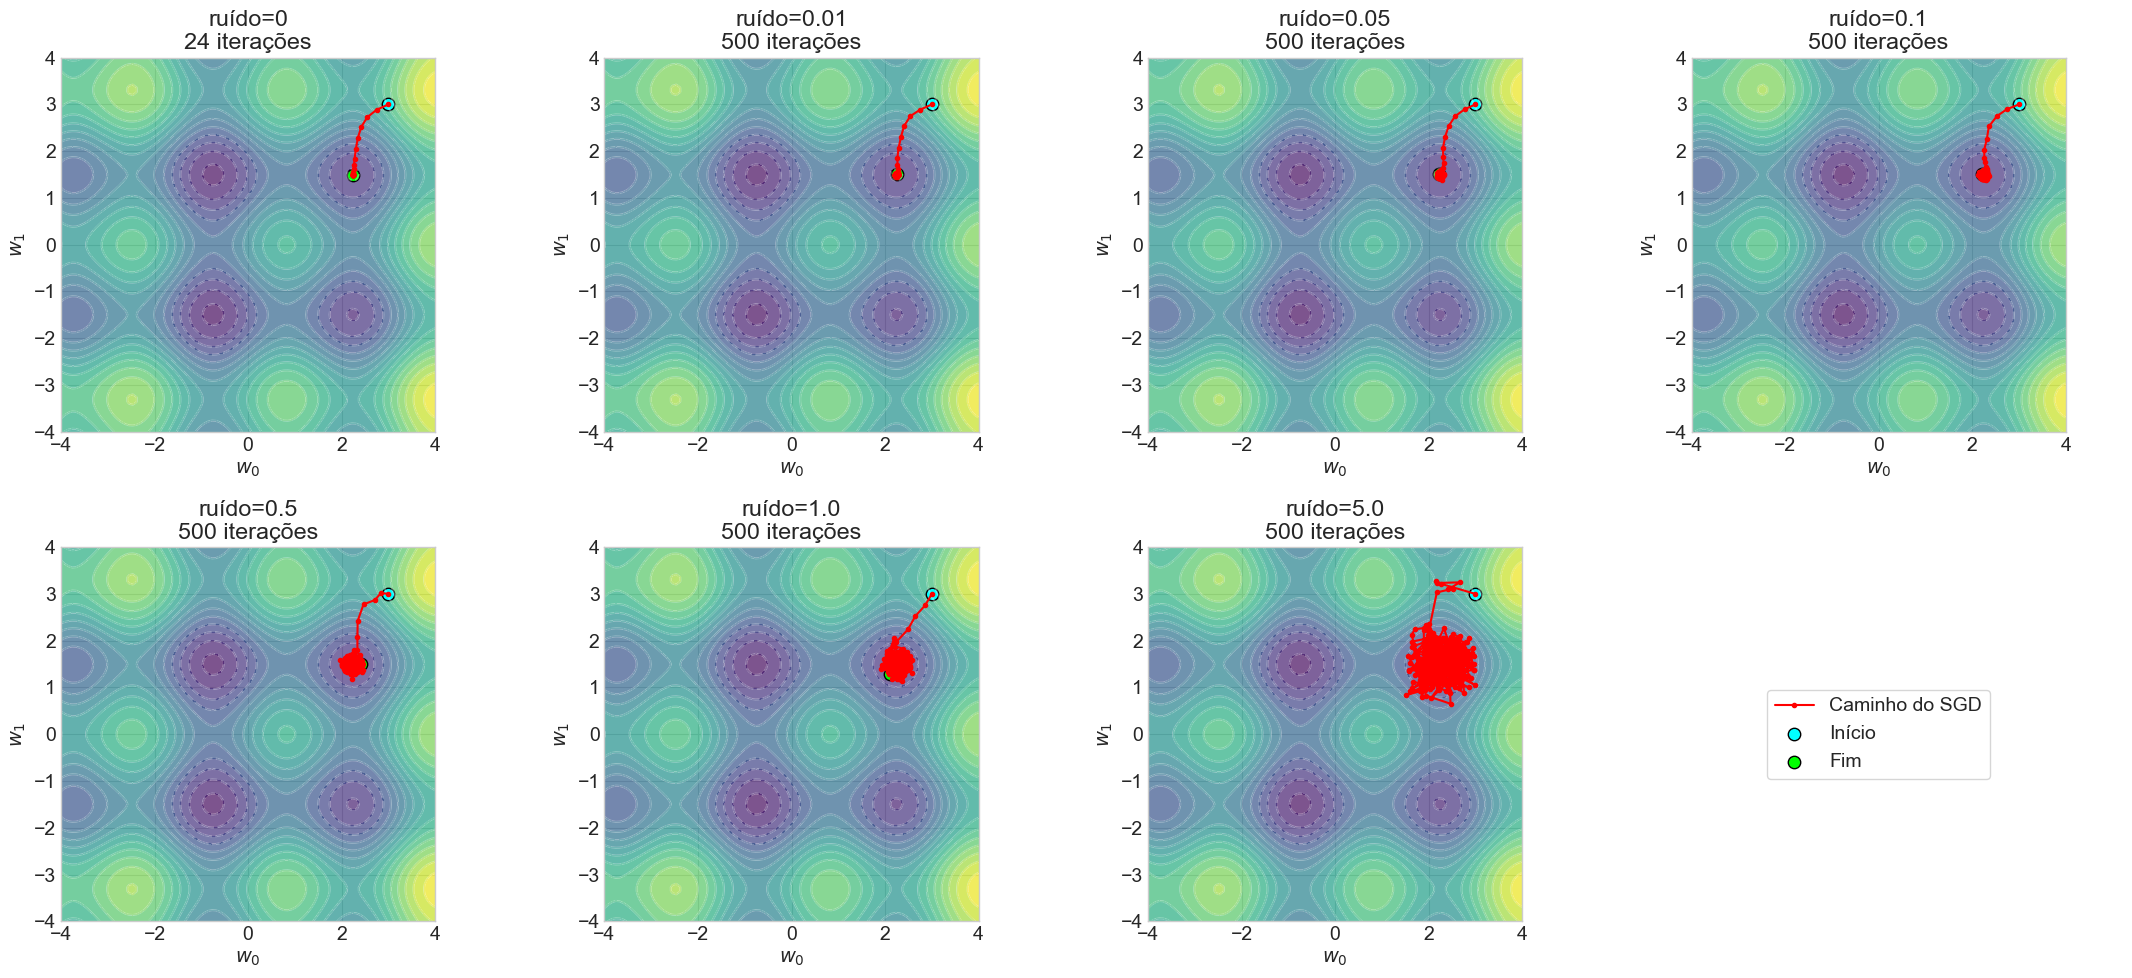

In [ ]:
# a funcao nao convexa do lab

def cost_function_2d(w):
    """Uma função de custo 2D não-convexa, mas suave."""
    return 0.1 * (w[0]**2 + w[1]**2) + (np.sin(2 * w[0]) + np.cos(2 * w[1]))

def gradient_2d(w):
    """O gradiente analítico da função de custo."""
    grad_w0 = 0.2 * w[0] + 2 * np.cos(2 * w[0])
    grad_w1 = 0.2 * w[1] - 2 * np.sin(2 * w[1])
    return np.array([grad_w0, grad_w1])



# treinar um limpo e 6 ruidosos
learning_rate = 0.1
start_point = np.array([3.0, 3.0])
tolerance = 1e-4
max_iterations = 500



noise_levels = [0, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

paths = {}
final_points = {}
iterations_dict = {}

for noise_level in noise_levels:
    
    # cria modelo para esse nível de ruído
    model_RNN = SimpleModel2D(start_point)
    optimizer = NoisyGD(model_RNN, learning_rate, noise_level)

    path = [model_RNN.w.copy()]
    iterations = 0

    for t in range(max_iterations):

        grad = gradient_2d(model_RNN.w)
        model_RNN.grad[:] = grad

        if np.linalg.norm(grad) < tolerance:
            break


        optimizer.step()
        optimizer.zero_grad()

        path.append(model_RNN.w.copy())
        iterations = t + 1

    paths[noise_level] = np.array(path)
    final_points[noise_level] = model_RNN.w.copy()
    iterations_dict[noise_level] = iterations

#plot 

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

w0_grid = np.linspace(-4, 4, 100)
w1_grid = np.linspace(-4, 4, 100)
W0, W1 = np.meshgrid(w0_grid, w1_grid)
Z = cost_function_2d([W0, W1])

legend_handles = None

for idx, noise_level in enumerate(noise_levels):
    ax = axes[idx]

    path = paths[noise_level]
    w_final = final_points[noise_level]
    iterations = iterations_dict[noise_level]

    ax.contourf(W0, W1, Z, levels=20, cmap='viridis', alpha=0.7)
    ax.contour(W0, W1, Z, levels=20, colors='white', alpha=0.3)

    
    line = ax.plot(path[:, 0], path[:, 1], 'o-', color = "red", markersize=3, 
                   label='Caminho do SGD')[0]

    
    start = ax.scatter(start_point[0], start_point[1], color='cyan', s=80,
                       edgecolors='black', label='Início')
    end = ax.scatter(w_final[0], w_final[1], color='lime', s=80,
                     edgecolors='black', label='Fim')

    
    if legend_handles is None:
        legend_handles = [line, start, end]

    ax.set_title(f"ruído={noise_level}\n{iterations} iterações")
    ax.set_xlabel("$w_0$")
    ax.set_ylabel("$w_1$")
    ax.set_aspect('equal')


ax_legend = axes[-1]
ax_legend.axis('off')  

ax_legend.legend(
    handles=legend_handles,
    labels=["Caminho do SGD", "Início", "Fim"],
    loc='center',
    fontsize=14,
    frameon=True
)

plt.tight_layout()
plt.show()


Plote dos caminhos sobre a mesma paisagem de custo. Discuta as diferenças. O ruído ajudou ootimizador a explorar a paisagem ou a escapar de mínimos locais?

**Resposta:** Nos testes efetuados, o resultado final entre os níveis de ruído menores se mostraram similares ao ruído 0. No ruído 0.5 e 1.0, é possível ver que o SGD caminhou bastante, tendo um caminho muito menos direto do que os iniciais, mas ainda sim, o resultado final foi similar ao ruído 0. No ruído 5.0, o nível de ruído começa a ser alto demais e o otimizador não consegue ter um caminho minimamente lógico, ele anda muito em círculos ao redor da região final. Apesar disso, todos os otimizadores convergiram para as mesmas regiões, é possível que isso aconteça por se tratar de uma função mais simples, em casos de problemas mais complexos, um nível de ruído pequeno (até 0.1) aparenta ajudar na "exploração" do mínimo e, por isso, pode ser interessante.

## Parte 2 - Implementação e Visualização

### Exercício 3: Implementando Otimizadores
Estenda o framework NumPy do laboratório anterior implementando as classes `MomentumSGD` e `Adam`.

3.1. Complete o método `step` da classe `MomentumSGD`.

In [9]:
class MomentumSGD:
    def __init__(self, model, learning_rate=0.01, momentum=0.9):
        self.model = model
        self.lr = learning_rate
        self.beta = momentum
        # Inicializar o buffer de velocidade para cada parâmetro
        self.velocities = [np.zeros_like(param) for param, grad in self.model.params()]

    def step(self):
        # Para cada parâmetro e gradiente:
        index = 0
        for param, grad in self.model.params():
            
            self.velocities[index] *= self.beta 
            self.velocities[index] -= self.lr * grad

            param += self.velocities[index]
            index += 1
    def zero_grad(self):
        for param, grad in self.model.params():
            grad.fill(0)


3.2. Complete o método `step` da classe `Adam`, incluindo a correção de viés.

In [ ]:
class Adam:
    def __init__(self, model, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.model = model
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0 # Contador de passos
        
        # Buffers para o 1o e 2o momentos
        self.m = [np.zeros_like(param) for param, grad in self.model.params()]
        self.v = [np.zeros_like(param) for param, grad in self.model.params()]

    def step(self):
        self.t += 1
        # Para cada parametro e gradiente:
        beta1 = self.beta1
        beta2 = self.beta2
        index = 0
        for param, grad in self.model.params():
            
            # 1. Atualize o 1o momento (m)
            
            self.m[index] = beta1 * self.m[index] + (1-beta1) * grad 
            
            # 2. Atualize o 2o momento (v)
            self.v[index] = beta2 * self.v[index] + (1 - beta2) * (grad*grad)

            # 3. Corrija o vies de m e v
            m_hat = self.m[index]/ (1 - beta1 **(self.t))
            v_hat = self.v[index]/ (1 - beta2 ** (self.t))

            # 4. Atualize o parametro
            param -= self.lr * m_hat/(np.sqrt(v_hat) + self.epsilon)
            
            index += 1

    def zero_grad(self):
        for param, grad in self.model.params():
            grad.fill(0)

#### 3. Treine um MLP no dataset `Duas Luas` com cada um dos três otimizadores (SGD, MomentumSGD, Adam) e plote suas curvas de custo (loss vs. épocas) em um único gráfico para comparar a velocidade de convergência.


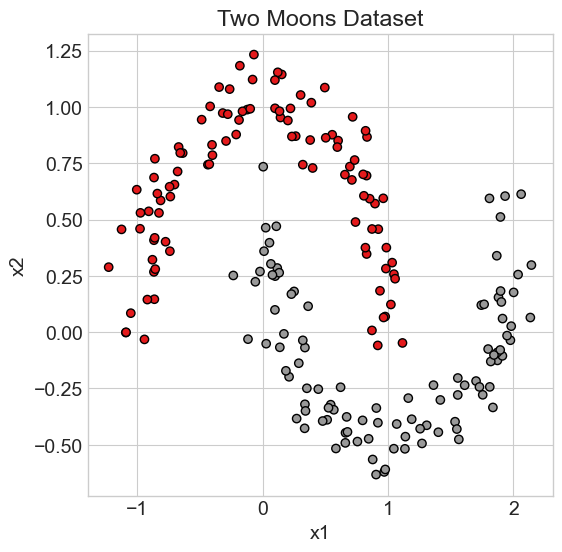

In [17]:
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
y_moons = y_moons.reshape(-1, 1) 

# plot
plt.figure(figsize=(6, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons.ravel(), cmap=plt.cm.Set1, edgecolor="k")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Two Moons Dataset")
plt.show()


In [18]:
def train_model(model, loss_fn, optimizer, X, y, epochs=5000, interval= 500):
    loss_history = []
    for epoch in range(epochs):
        y_pred = model.forward(X)

        loss = loss_fn.forward(y_pred, y)
        loss_history.append(loss)

        optimizer.zero_grad()

        grad_initial = loss_fn.backward()

        model.backward(grad_initial)
        optimizer.step()

        if (epoch+1) % interval == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss:.4f}')
    return model, loss_history

loss_fn = BinaryCrossEntropyLoss()

In [19]:
model_moons_sgd = Sequential([
    Linear(2, 16),
    ReLU(),
    Linear(16, 1),
    Sigmoid()
])
# Instanciar os componentes
sgd_optimzer_moons = SGD(model_moons_sgd, learning_rate=0.1)
print("SGD:")
_ , loss_history_moons_SGD = train_model(model= model_moons_sgd, loss_fn= loss_fn, optimizer=sgd_optimzer_moons, X =X_moons, y=y_moons)

SGD:
Epoch [500/5000], Loss: 0.2736
Epoch [1000/5000], Loss: 0.2723
Epoch [1500/5000], Loss: 0.2718
Epoch [2000/5000], Loss: 0.2703
Epoch [2500/5000], Loss: 0.2641
Epoch [3000/5000], Loss: 0.2507
Epoch [3500/5000], Loss: 0.2404
Epoch [4000/5000], Loss: 0.2363
Epoch [4500/5000], Loss: 0.2345
Epoch [5000/5000], Loss: 0.2336


In [20]:
model_moons_momentum = Sequential([
    Linear(2, 16),
    ReLU(),
    Linear(16, 1),
    Sigmoid()
])
print("SGD MOMENTUM:")

momentum_optimzer_moons = MomentumSGD(model_moons_momentum, learning_rate= 0.1) # lr = 0.01
_ , loss_history_moons_momentum = train_model(model= model_moons_momentum, loss_fn= loss_fn, optimizer=momentum_optimzer_moons, X =X_moons, y=y_moons)


SGD MOMENTUM:
Epoch [500/5000], Loss: 0.0241
Epoch [1000/5000], Loss: 0.0078
Epoch [1500/5000], Loss: 0.0044
Epoch [2000/5000], Loss: 0.0029
Epoch [2500/5000], Loss: 0.0022
Epoch [3000/5000], Loss: 0.0017
Epoch [3500/5000], Loss: 0.0014
Epoch [4000/5000], Loss: 0.0012
Epoch [4500/5000], Loss: 0.0010
Epoch [5000/5000], Loss: 0.0009


In [45]:
model_moons_adam = Sequential([
    Linear(2, 16),
    ReLU(),
    Linear(16, 1),
    Sigmoid()
])
adam_optimzer_moons = Adam(model= model_moons_adam, learning_rate= 0.1) # lr = 0.001
print("ADAM:")
_ , loss_history_moons_ADAM = train_model(model= model_moons_adam, loss_fn= loss_fn, optimizer=adam_optimzer_moons, X =X_moons, y=y_moons,epochs= 1500, interval= 150)


ADAM:
Epoch [150/1500], Loss: 0.0027
Epoch [300/1500], Loss: 0.0008
Epoch [450/1500], Loss: 0.0004
Epoch [600/1500], Loss: 0.0002
Epoch [750/1500], Loss: 0.0001
Epoch [900/1500], Loss: 0.0001
Epoch [1050/1500], Loss: 0.0001
Epoch [1200/1500], Loss: 0.0001
Epoch [1350/1500], Loss: 0.0000
Epoch [1500/1500], Loss: 0.0000


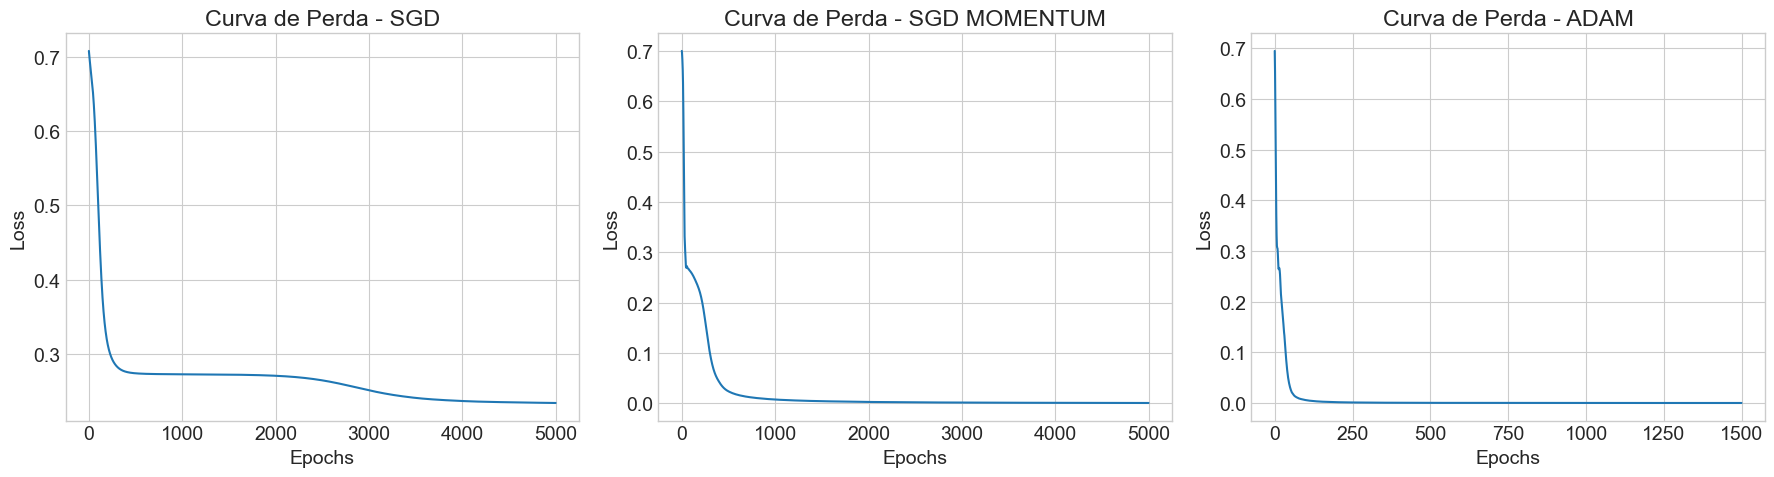

In [46]:
def plot_loss(loss1, loss2, loss3, names=["SGD", "SGD MOMENTUM", "ADAM"]):
    fig, axs = plt.subplots(1, 3, figsize=(18,5))  
    histories = [loss1, loss2, loss3]
    for i in range(3):
        axs[i].plot(histories[i])
        axs[i].set_title(f"Curva de Perda - {names[i]}")
        axs[i].set_xlabel("Epochs")
        axs[i].set_ylabel("Loss")
        axs[i].grid(True)

    plt.tight_layout()
    plt.show()
plot_loss(loss_history_moons_SGD, loss_history_moons_momentum, loss_history_moons_ADAM)

### Exercício 4: Visualizando a dinâmica de otimização

Para este exercício, vamos "congelar"as camadas iniciais de um MLP treinado e visualizar a
paisagem de custo apenas em relação aos parâmetros da última camada linear.

1. Paisagem de Custo: Crie uma grade 2D de valores para dois dos pesos da última camada. Para cada ponto na grade, calcule o custo total do dataset. Use `plt.contourf` para visualizar a paisagem de custo.


In [ ]:
def plot_last_layer_cost_landscape(model, X, y, loss_fn, name = None,
                                   idx1=(0,0), idx2=(5,0),
                                   span=1.0, resolution=40):

    params = list(model.params())
    last_W, _ = params[-2]   # penúltimo elemento é W_L (antes do bias)
    
    W_orig = last_W.copy()
    
    w1_center = W_orig[idx1]
    w2_center = W_orig[idx2]
    
    w1_vals = np.linspace(w1_center - span, w1_center + span, resolution)
    w2_vals = np.linspace(w2_center - span, w2_center + span, resolution)

    Z = np.zeros((resolution, resolution))

    for i, w1 in enumerate(w1_vals):
        for j, w2 in enumerate(w2_vals):
            
            # Congelar toda a rede e só alterar esses dois pesos
            last_W[:] = W_orig[:]  
            last_W[idx1] = w1
            last_W[idx2] = w2

            logits = model.forward(X)
            Z[i,j] = loss_fn.forward(logits, y)

    last_W[:] = W_orig[:]  

    plt.figure(figsize=(8,6))
    plt.contourf(w1_vals, w2_vals, Z.T, levels=30, cmap='viridis')
    plt.colorbar(label="Custo")
    plt.xlabel(f"W_last{idx1}")
    plt.ylabel(f"W_last{idx2}")
    plt.title(f"Paisagem de Custo {name} — Última Camada")
    plt.show()

2. Caminho do Otimizador: Sobre a paisagem de custo, plote o caminho percorrido pelos pesos da última camada durante o treinamento para o SGD e para o Adam.

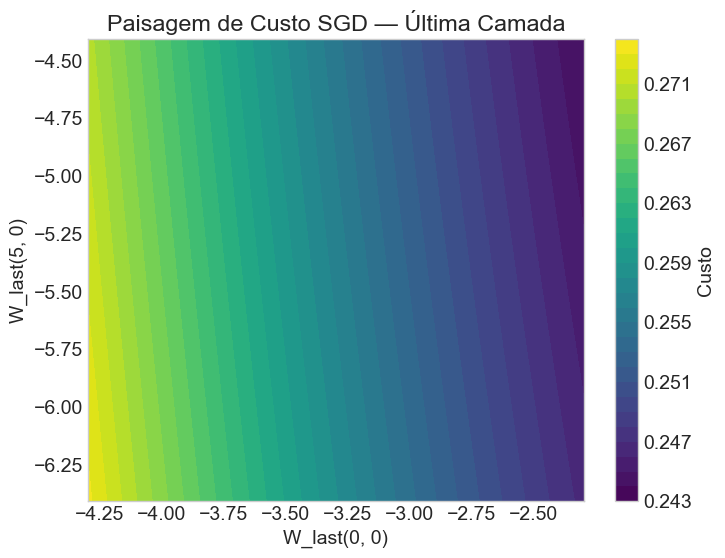

In [41]:
plot_last_layer_cost_landscape(model_moons_sgd, 
                                X= X_moons, y= y_moons, loss_fn= loss_fn, name= "SGD", idx1= (0,0), idx2 = (5,0))

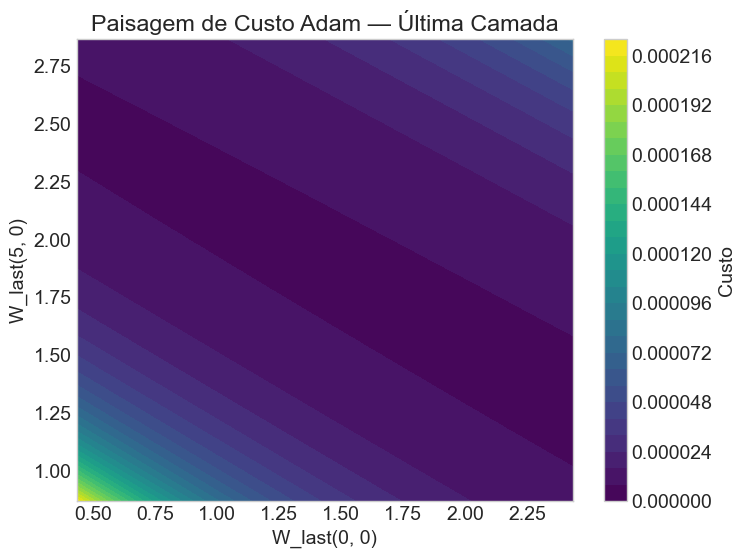

In [42]:
plot_last_layer_cost_landscape(model_moons_adam,
                                X= X_moons, y= y_moons, loss_fn= loss_fn, name = "Adam", idx1= (0,0), idx2 = (5,0))

3. Análise: Compare os dois caminhos. O caminho do Adam é mais direto? O do SGD é mais ruidoso? O que isso lhe diz sobre o comportamento de cada otimizador?

**Resposta:**

O resultado dos gráficos ressalta a ideia do `exercício 1.1`, sobre mínimos planos e afiados. As linhas do gráfico do SGD são bastantes verticais e suaves, enquanto as do adam são bastante inclinadas e algumas são bem grossas. Isso reforça que, enquanto o SGD encontra mínimos planos e suaves, por causa da sua natureza ruidosa, o ADAM encontra mínimos afiados, por causa da maneira que ele lida com gradientes muito altos, com a taxa de aprendizado adaptativa.

### Exercício 5: Implementações em Pytorch (bônus)

Complete a implementação do laboratório de RNNs, plote as curvas da loss e norma do gradiente
para frases de tamanho pequeno, médio e longo, efetuando uma análise sobre os diferentes
comportamentos para três tipos de frases e dois otimizadores (SGD e Adam).

Carregando o dataset de palavras

In [ ]:
dataset = load_dataset("rotten_tomatoes")
# Tokenizador simples baseado em espaço
tokenizer = lambda text: text.lower().split()

# --- Construção Manual do Vocabulário ---
word_counts = Counter()
for item in dataset['train']:
    word_counts.update(tokenizer(item['text']))

vocab_list = sorted(word_counts, key=word_counts.get, reverse=True)
word_to_idx = {word: i+2 for i, word in enumerate(vocab_list)} # Começa do 2 para os tokens especiais
word_to_idx['<pad>'] = 0
word_to_idx['<unk>'] = 1
vocab_size = len(word_to_idx)
pad_idx = word_to_idx['<pad>']

text_pipeline = lambda x: [word_to_idx.get(token, word_to_idx['<unk>']) for token in tokenizer(x)]

# Separar os dados por comprimento de frase
train_data = list(dataset['train'])
short_sentences = [item for item in train_data if len(tokenizer(item['text'])) <= 10]
medium_sentences = [item for item in train_data if 10 < len(tokenizer(item['text'])) <= 30]
long_sentences = [item for item in train_data if len(tokenizer(item['text'])) > 30]


In [ ]:
class TextDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]['text'], self.data[idx]['label']

def collate_batch(batch):
    label_list, text_list = [], []
    for (_text, _label) in batch:
        label_list.append(float(_label))
        processed_text = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(processed_text)
    
    labels = torch.tensor(label_list, dtype=torch.float32)  # float!
    texts  = nn.utils.rnn.pad_sequence(text_list,padding_value=pad_idx,batch_first=True)
    return labels, texts

#    return torch.tensor(label_list, dtype=torch.int64), nn.utils.rnn.pad_sequence(text_list, padding_value=pad_idx, batch_first=True)

short_loader = DataLoader(TextDataset(short_sentences), batch_size=32, shuffle=True, collate_fn=collate_batch)
medium_loader = DataLoader(TextDataset(medium_sentences), batch_size= 32, shuffle = True, collate_fn=collate_batch)
long_loader = DataLoader(TextDataset(long_sentences), batch_size=32, shuffle=True, collate_fn=collate_batch)

In [117]:
def grad_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.detach().data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

In [145]:
def train(model, epochs, dataloader, optimizer, criterion):
    model.train()
    loss_history = []
    acc_curve = []
    grad_norm_hist = []
    for epoch in range(epochs):

        total_loss = 0.0
        total_acc = 0
        total_samples = 0
        for labels, text in dataloader:
            labels, text = labels.to(device), text.to(device)

            optimizer.zero_grad()
            
            output = model(text)
            output = output.squeeze(0)

            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            probs = torch.sigmoid(output)
            preds = (probs > 0.5).long()
        
            total_acc += (preds== labels).sum().item()
            total_samples += text.size(0)

        epoch_loss = total_loss / total_samples
        epoch_acc  = total_acc / total_samples
        
        loss_history.append(epoch_loss)
        acc_curve.append(epoch_acc)
        grad_norm_hist.append(grad_norm(model))

        #if (epoch +1) % 10 == 0:
            #print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    return loss_history, acc_curve, grad_norm_hist

embed_dim = 100
hidden_dim = 128
output_dim = 1

1. Implemente o RNN Simples

In [108]:
class SimpleRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.layer_xh = nn.Linear(input_size,hidden_size, bias= True)
        self.layer_hh = nn.Linear(hidden_size, hidden_size, bias= True)

    def forward(self, x_t, h_prev):
        return torch.tanh(self.layer_xh(x_t) + self.layer_hh(h_prev))

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn_cell = SimpleRNNCell(embed_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)
        h = torch.zeros(text.size(0), self.rnn_cell.hidden_size).to(device)
        
        for t in range(text.size(1)):
            h = self.rnn_cell(embedded[:, t, :], h)
        
        return self.fc(h).squeeze(1)
    

2. Implemente LSTM e GRU.


In [100]:
class SimpleLSTMCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        
        self.Wx = nn.Linear(input_size, 4* hidden_size)
        self.Wh = nn.Linear(hidden_size, 4* hidden_size, bias= False)

    def forward(self, x_t, h_prev, c_prev):
        gates = self.Wx(x_t) + self.Wh(h_prev)
        i, f, g, o = gates.chunk(4, dim = 1)

        i = torch.sigmoid(i)
        f = torch.sigmoid(f)
        g = torch.sigmoid(g)
        g = torch.tanh(g)

        c_t = f * c_prev + i * g
        h_t = o * torch.tanh(c_t)
        return  h_t, c_t
    
class SimpleLSTMLayer(nn.Module):
    def __init__(self, input_size, hidden_size, batch_first = True):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = SimpleLSTMCell(input_size, hidden_size)
        self.batch_first = batch_first
    def forward(self, text):

        
        batch_size , seq_len ,_ = text.size()
    

        h = torch.zeros(batch_size, self.hidden_size).to(device)
        c = torch.zeros(batch_size, self.hidden_size).to(device)

        outputs = []

        for t in range(seq_len):
            h, c = self.cell(text[:, t, :], h, c)
            outputs.append(h.unsqueeze(1))

        outputs = torch.cat(outputs, dim=1)

        return outputs, (h.unsqueeze(0), c.unsqueeze(0))

In [94]:
class SimpleGRUCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_dim
        self.Wx = nn.Linear(input_size, 3 * hidden_size)
        self.Wh = nn.Linear(hidden_size, 3 * hidden_size)

    def forward(self, x_t, h_prev):
        gates = self.Wx(x_t) + self.Wh(h_prev)

        r, z , h_til = gates.chunk(3, dim = 1)

        r = torch.sigmoid(r)
        z = torch.sigmoid(z)        
        h_til = torch.tanh(h_til)

        h_t = (1-z) * h_prev + z * h_til

        return h_t

class SimpleGRU(nn.Module):
    def __init__(self, input_size, hidden_size, batch_first =True):
        super().__init__()
        self.hidden_size = hidden_size
        self.cell = SimpleGRUCell(input_size, hidden_size)
        self.batch_first = batch_first

    def forward(self, text):

        batch_size , seq_len ,_ = text.size()
    

        h = torch.zeros(batch_size, self.hidden_size).to(device)

        outputs = []

        for t in range(seq_len):
            h = self.cell(text[:, t, :], h)
            outputs.append(h.unsqueeze(1))
        
        outputs = torch.cat(outputs, dim = 1)

        return outputs, h.unsqueeze(0)

In [ ]:
class AdvancedRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, rnn_layer):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn = rnn_layer(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, text):
        embedded = self.embedding(text)

        # A saída da RNN/LSTM/GRU é (output, hidden_state)
        # Para LSTM, hidden é uma tupla (h_n, c_n)
        # Para GRU e RNN, hidden é apenas h_n
        _, hidden = self.rnn(embedded)
        
        if isinstance(hidden, tuple):
            hidden = hidden[0]
        return self.fc(hidden.squeeze(0)).squeeze(1)


# TODO: Instancie e treine um modelo com suas implementacoes de LSTM, GRU, nn.LSTM e outro com nn.GRU
# no `long_loader`. Compare os resultados com a SimpleRNN.

3. Implemente RNN com ReLU

In [113]:
class ResRNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        self.W_xh = nn.Linear(input_size, hidden_size)
        self.W_hh = nn.Linear(hidden_size, hidden_size)
        self.activation = nn.ReLU()

    def forward(self, x_t, h_prev):
        # Equação da ResRNN: h_t = relu(W_xh*x_t + W_hh*h_{t-1} + h_{t-1})
        h_t = self.W_xh(x_t) + self.W_hh(h_prev) + h_prev
        return self.activation(h_t)
    
class ResRNNLayer(nn.Module):
    def __init__(self, input_size, hidden_size, batch_first = True):
        super().__init__()       
        self.cell = ResRNNCell(input_size, hidden_size)
        self.hidden_size = hidden_size
        self.batch_first = batch_first

    def forward(self, text, h_0 = None):
        batch_size, seq_len, _ = text.size()
        h_t = torch.zeros(batch_size, self.hidden_size, device=text.device)
        outputs = []
        for t in range(seq_len):
            h_t = self.cell(text[:, t], h_t)
            outputs.append(h_t.unsqueeze(1))
        
        outputs = torch.cat(outputs, dim=1)
        return outputs, h_t.unsqueeze(0) 



#### Comparação entre Modelos

In [ ]:
def plot_loader_results(loader_name, results_for_loader, model_names, opt_names):

    num_models = len(model_names)

    fig, axes = plt.subplots(2, num_models, figsize=(5*num_models, 9))
    fig.suptitle(f"Resultados no Loader: {loader_name}", fontsize=22)

    colors = {
        opt_names[0]: "blue",   
        opt_names[1]: "red"     
    }

    for col, model_name in enumerate(model_names):

        # Linha 1 - Loss
        
        ax_loss = axes[0, col]
        ax_loss.set_title(f"{model_name} - Loss")
        ax_loss.set_xlabel("Epoch")
        ax_loss.set_ylabel("Loss")

        # Linha 2 - Grad Norm
        ax_grad = axes[1, col]
        ax_grad.set_title(f"{model_name} - Gradient Norm")
        ax_grad.set_xlabel("Epoch")
        ax_grad.set_ylabel("||grad||")

        for opt_name in opt_names:
            data = results_for_loader[model_name][opt_name]

            ax_loss.plot(data["loss"], label=opt_name, color=colors[opt_name])
            ax_grad.plot(data["grad"], label=opt_name, color=colors[opt_name])

        ax_loss.legend()
        ax_grad.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()


In [ ]:
def compare_models(models, model_names, optimizers, opt_names, loaders, loss_fn):

    results = {}

    for loader_name, loader in loaders.items():
        print(f"Loader: {loader_name} ---")
        results[loader_name] = {}

        for model_name, model_constructor in zip(model_names, models):
            print(f"\nModelo: {model_name}")
            

            results[loader_name][model_name] = {}

            for opt_name, opt_constructor in zip(opt_names, optimizers):
                #print(f"  → Otimizador: {opt_name}")

                model = model_constructor() 
                optimizer = opt_constructor(model.parameters())

                loss_hist, acc_hist, grad_hist = train(
                    model=model,
                    dataloader=loader,
                    optimizer=optimizer,
                    criterion=loss_fn,
                    epochs=50
                )

                results[loader_name][model_name][opt_name] = {
                    "loss": loss_hist,
                    "acc": acc_hist,
                    "grad": grad_hist
                }

        # Após treinar **todos os modelos nesse loader**, plotar:
        plot_loader_results(loader_name, results[loader_name], model_names, opt_names)

    return results


In [141]:

models = [
    lambda: SimpleRNN(vocab_size, embed_dim, hidden_dim, output_dim, pad_idx),
    lambda: AdvancedRNN(vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, rnn_layer=SimpleLSTMLayer),
    lambda: AdvancedRNN(vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, rnn_layer=nn.LSTM),
    lambda: AdvancedRNN(vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, rnn_layer=SimpleGRU),
    lambda: AdvancedRNN(vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, rnn_layer=nn.GRU),
    lambda: AdvancedRNN(vocab_size, embed_dim, hidden_dim, output_dim, pad_idx, rnn_layer=ResRNNLayer),
]
model_names = ["RNN Simples", "LSTM Simples", "nn.LSTM", "GRU Simples", "nn.GRU", "ResRNN ReLu"]

optim_ADAM = optim.Adam
optim_SGD = optim.SGD
optimizers=[lambda p: optim.Adam(p), lambda p: optim.SGD(p, lr=0.01, momentum=0.9)]

opt_names = ["ADAM", "SGD"]

loaders = {"small": short_loader, "medium": medium_loader, "long": long_loader}

loss_fn = nn.BCEWithLogitsLoss()


In [ ]:
compare_models(
    models= models,
    model_names= model_names,
    optimizers= optimizers,
    opt_names= opt_names,
    loaders= loaders,
     loss_fn= loss_fn
) #

#### Análise dos Resultados

- **Short Loader**: 

    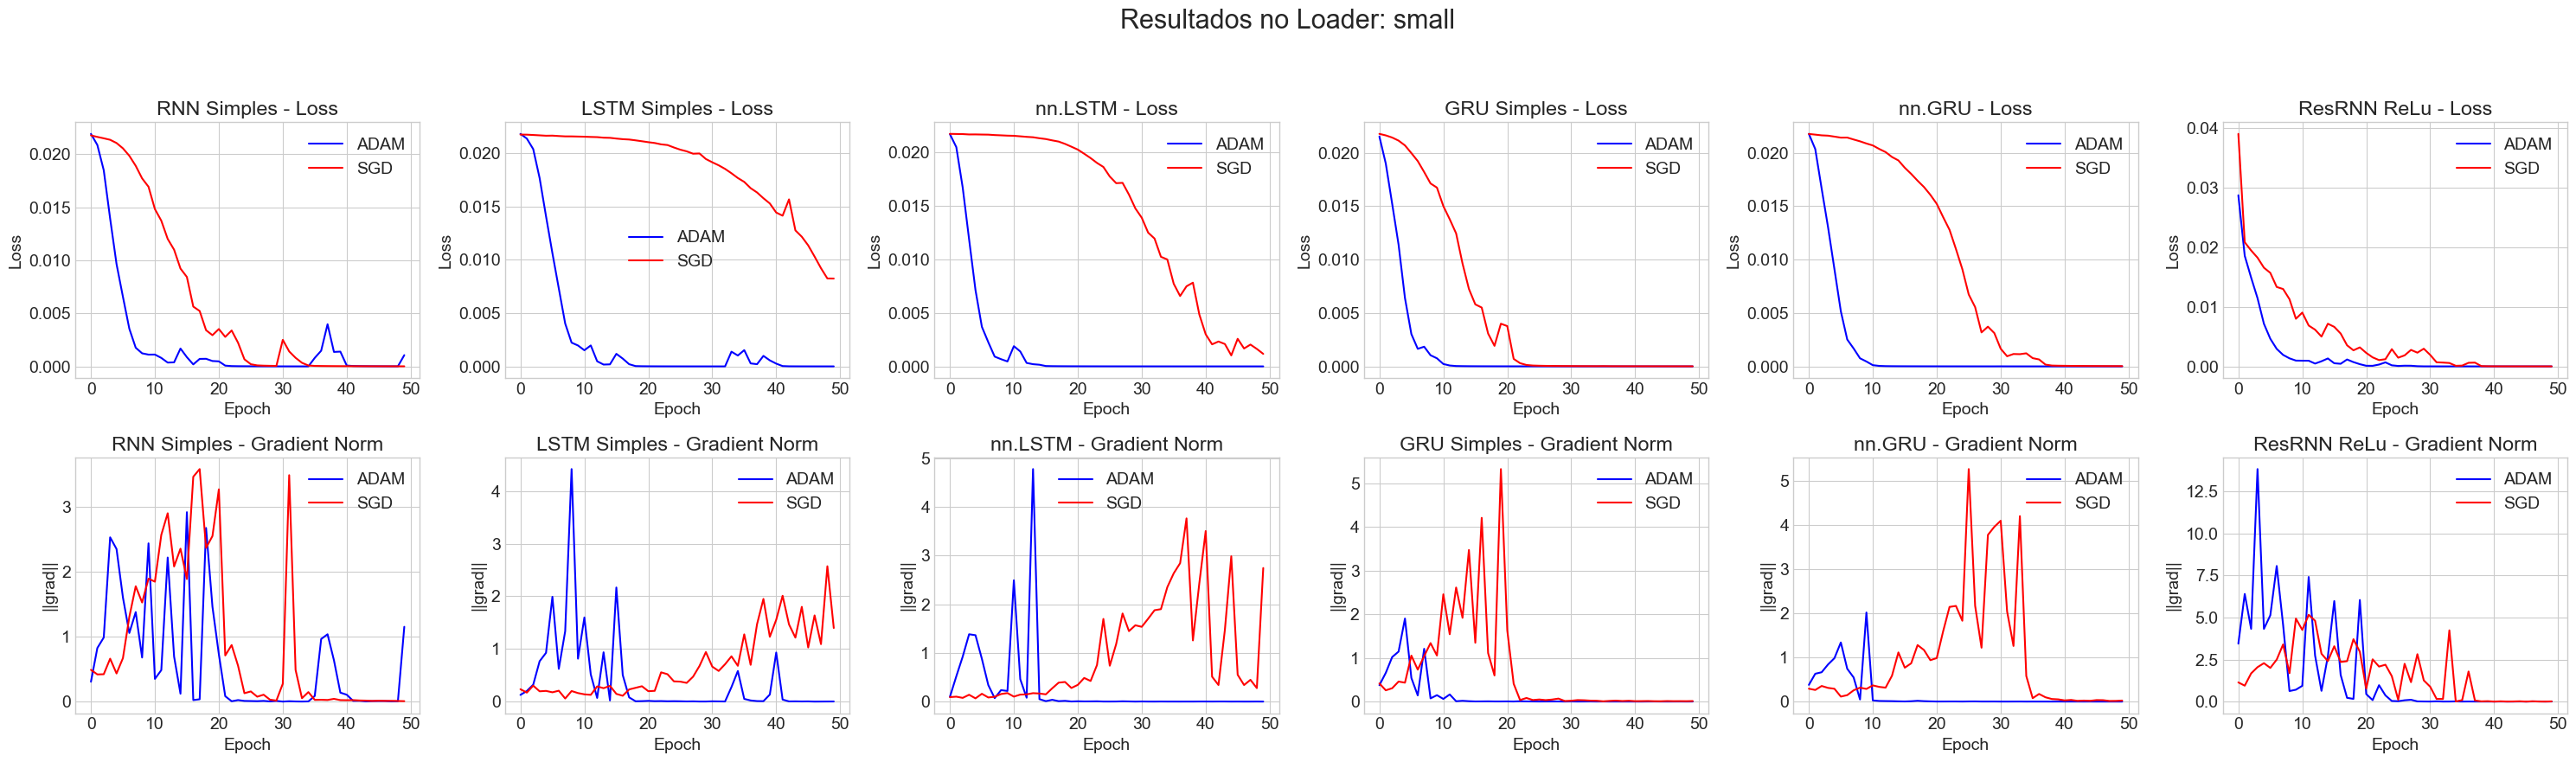
    
    - As curvas de perda de quase todos os modelos, para ambos otimizadores, conseguiram chegar ao valor de quase 0. A única exceção foi o SGD no LSTM Simples que não conseguiu convergir, e possível que com mais algumas épocas ele chegasse na convergência. 
    - As normas de gradiente variaram bastante para cada modelo. Em geral o ADAM se comportou de maneira mais estável, o que faz sentido, dada a maneira que ele lida com os gradientes, enquanto o SGD possui muitas variaçõoes ao longo das épocas. O único modelo em que o ADAM teve um comportamento mais instável foi o RNN Simples, mas que depois de algumas épocas também foi estabilizado.

- **Medium Loader**:

    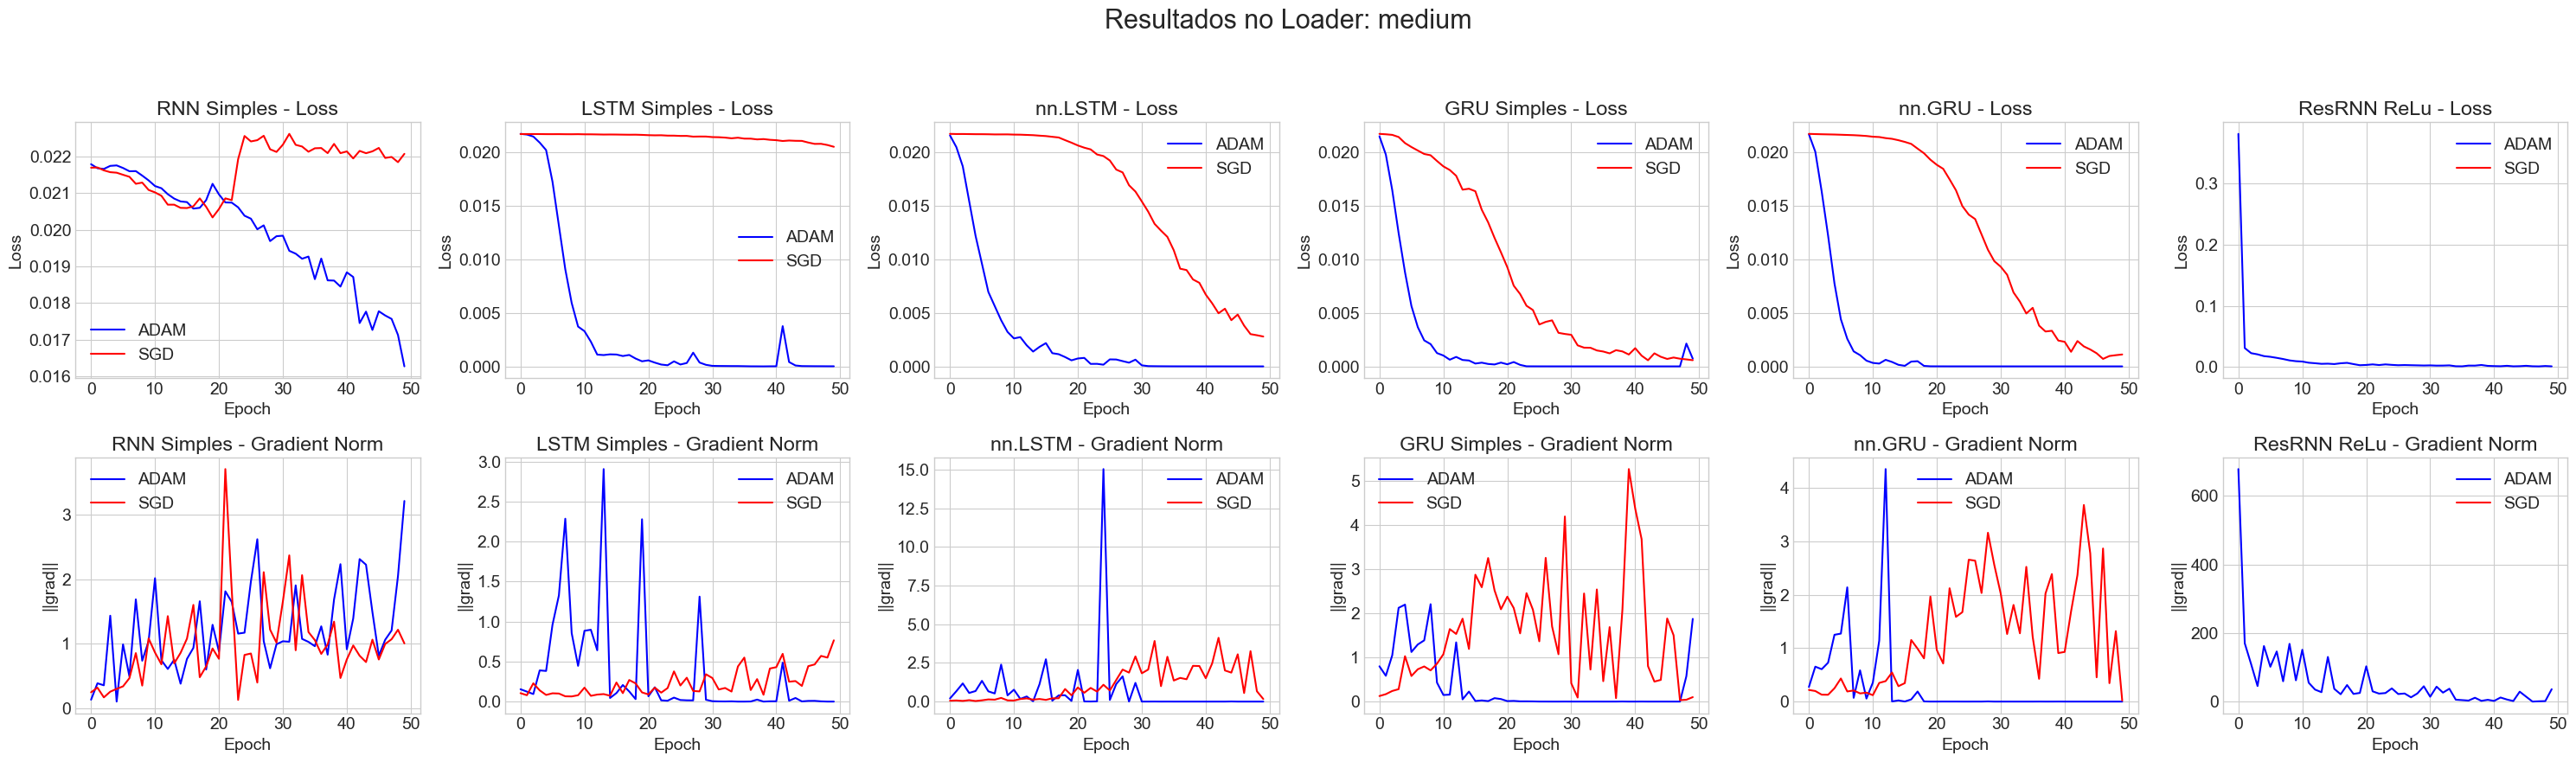

    - Como no short, as curvas de perda em geral, foram similares, com os modelos conseguindo convergir para valores baixos, e com o ADAM obtendo a convergência mais rápida. O RNN Simples e o LSTM Simples foram os dois pontos mais diferentes, o primeiro não conseguiu convergir de maneira satisfatória para nenhum dos dois otimizadores e, no segundo, o SGD não conseguiu convergir.
    - As normas de gradiente dos modelos se comportamram de maneira parecida com suas versões do short loader. O RNN Simples foi o que sofreu mais variações para os dois otimizadores, e o ADAM conseguiu se manter mais estável ao longo das épocas.

- **Long Loader**:

    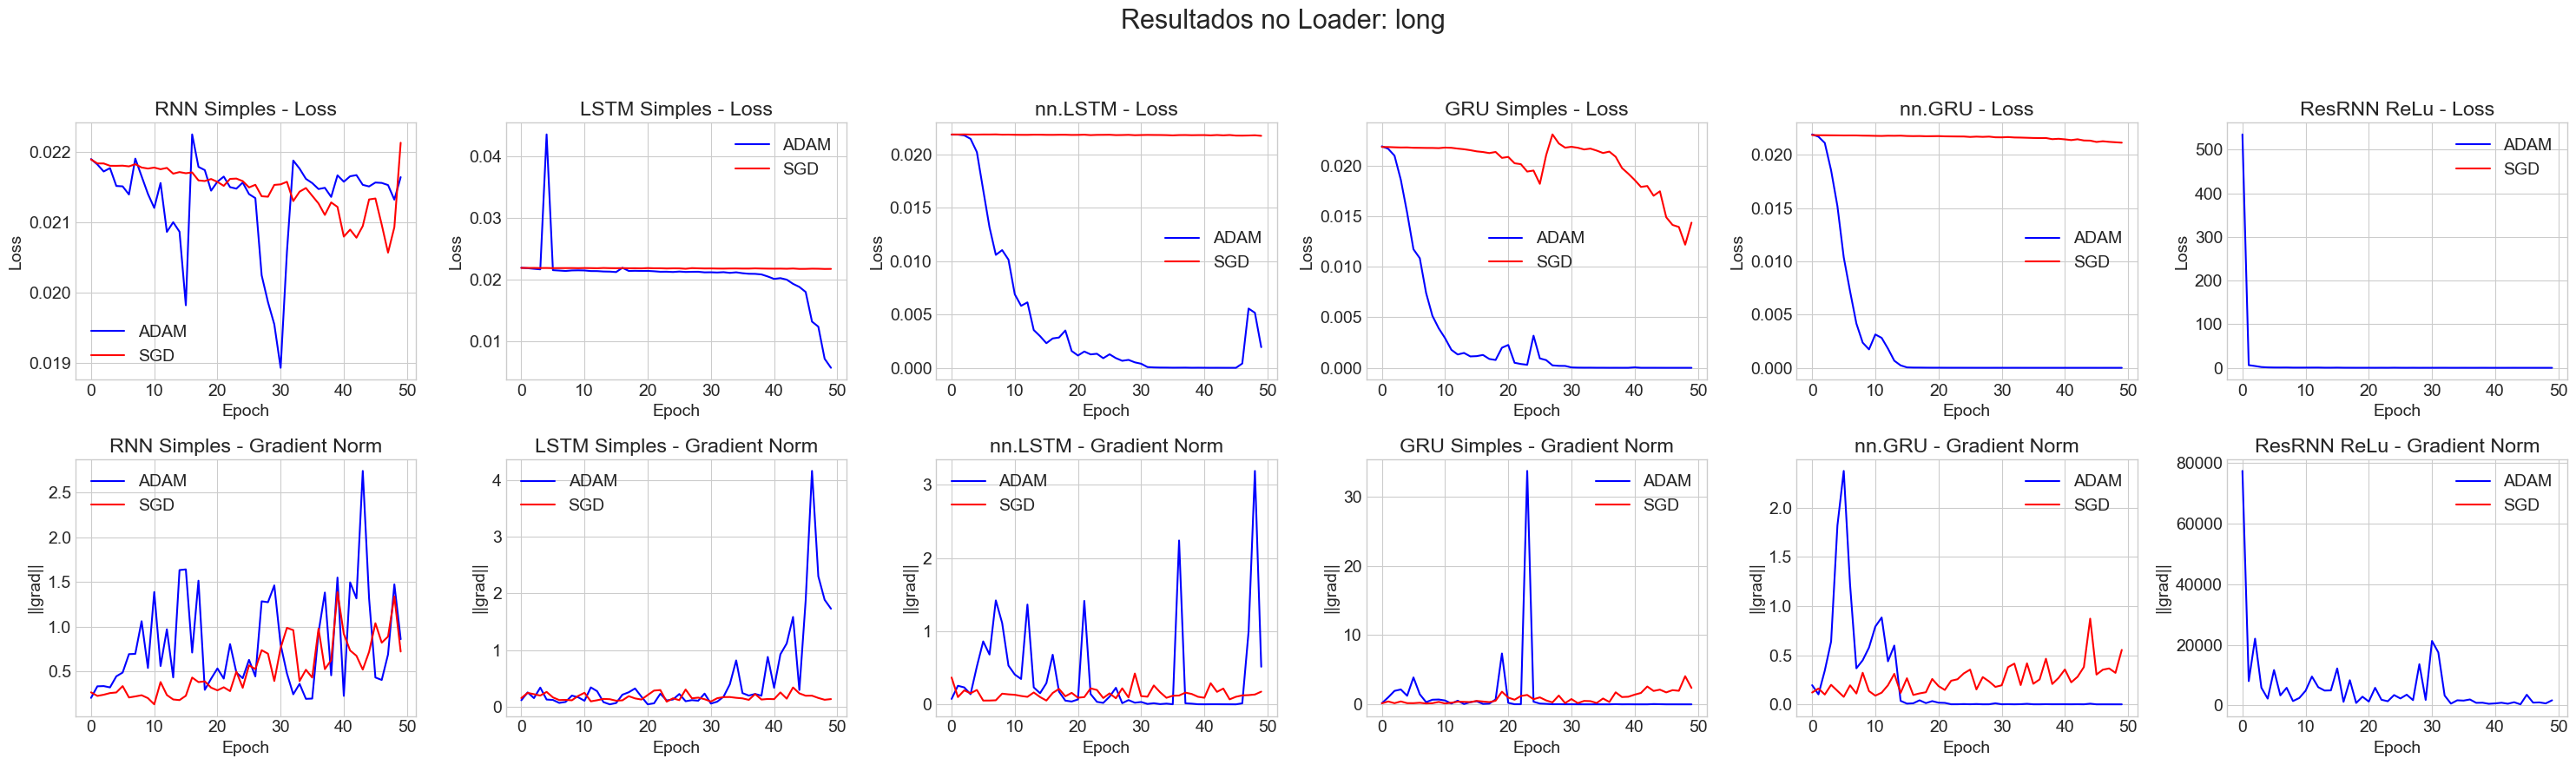

    - Aqui temos uma diferença importante, nos outros casos, o SGD conseguiu convergir, mesmo com certa dificuldade, no gráfico de perda. Aqui, em nenhum caso o SGD teve um "movimento" de convergência característico, a diminuição da perda, pelo contrário, na maioria dos casos ele permaneceu "estático" ou pouco se moveu. O ADAM, por outro lado, conseguiu se sair bem em quase todos os casos, diferindo apenas no RNN simples, o que pode ser explicado pelas limitações do modelo de RNN simples para sentenças longas. 
    
    - As normas de gradiente, nos confirmam o comportamento visto nas curvas de perda, o SGD pouco se move, e o ADAM se mostra mais estável para quase todos os modelos, diferindo apenas nos modelo de RNN simples, que ele parece perdido e nos modelos de LSTM, que ele ainda parece estar tentando encontrar o mínimo quando as iterações acabam.


**Conclusão:**
- Pensando no caso que iríamos tentar utilizar um modelo só para os 3 casos de loaders, os modelo de GRU e ResRNN, ambos com ADAM, se mostraram os mais capazes para essa tarefa, obtendo resultados satisfatórios nos 3.